### 예시로 익숙해지기 (선형 회귀)

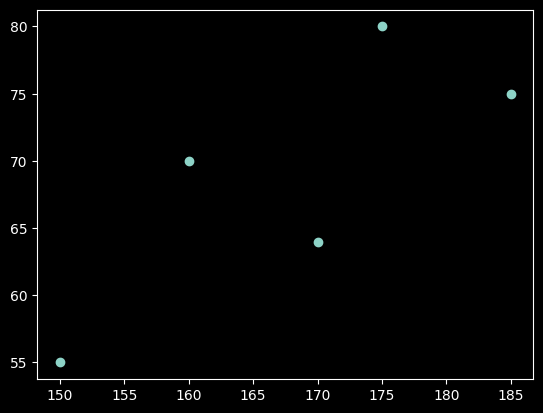

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = [150, 160, 170, 175, 185]  # 키
y = [55, 70, 64, 80, 75]  # 몸무게
plt.plot(x, y, "o")

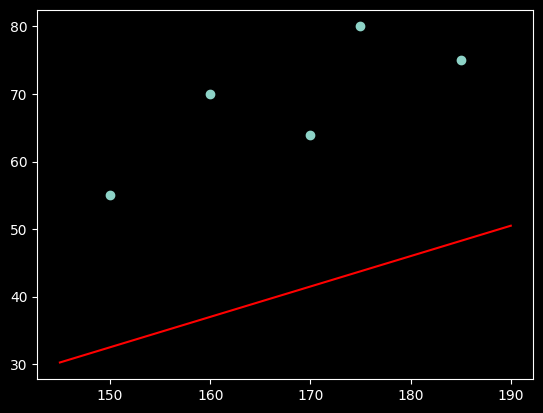

In [ ]:
a = 0.45
b = -35
x_plot = np.linspace(145, 190, 100)
y_plot = a * x_plot + b

plt.plot(x, y, "o")
plt.plot(x_plot, y_plot, "r")

optimal a = [0.56262626]
optimal b = [-25.75757576]


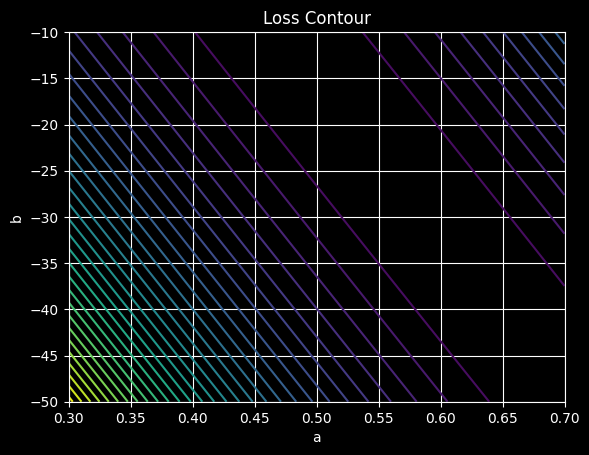

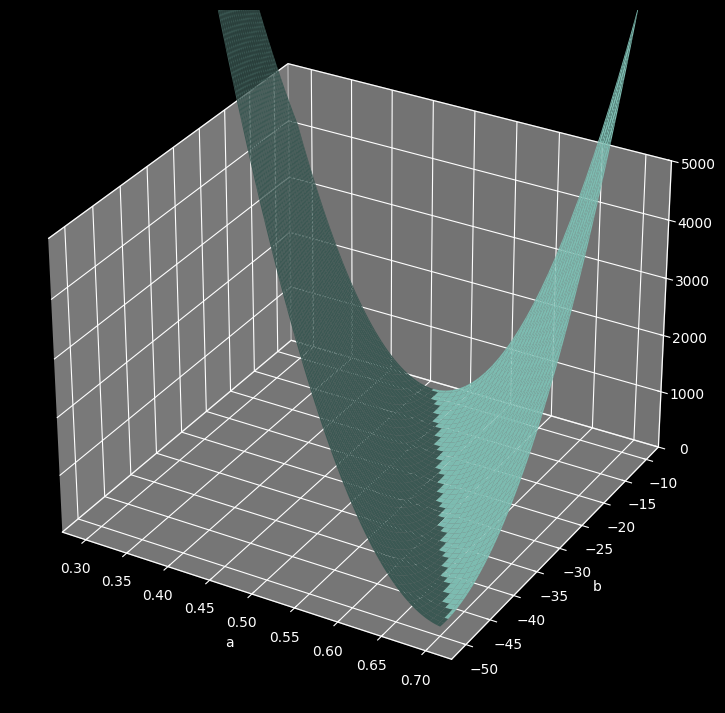

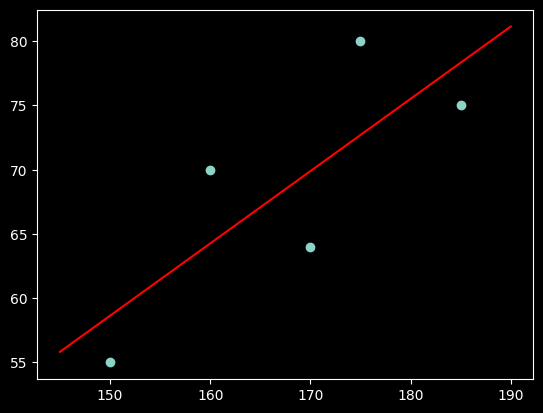

In [ ]:
a = 0.5 + np.linspace(-0.2, 0.2, 100)
b = -30 + np.linspace(-20, 20, 100)

A, B = np.meshgrid(a, b)

L = np.zeros_like(A)
for xi, yi in zip(x, y):
    L += (yi - (A * xi + B)) ** 2

plt.figure()
plt.contour(a, b, L, 30)
plt.xlabel("a")
plt.ylabel("b")
plt.title("Loss Contour")
plt.grid()

plt.figure(figsize=(10, 9))
ax = plt.axes(projection="3d")
ax.plot_surface(A, B, L)
plt.xlabel("a")
plt.ylabel("b")
ax.set_zlim([0, 5000])

a_opt = A[L == np.min(L)]
b_opt = B[L == np.min(L)]

print(f"optimal a = {a_opt}")
print(f"optimal b = {b_opt}")

plt.figure()
y_plot = a_opt * x_plot + b_opt
plt.plot(x, y, "o")
plt.plot(x_plot, y_plot, "r")

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(x=a, y=b, z=L, colorscale="viridis", opacity=0.5)])
fig.update_traces(
    contours_z=dict(
        show=True, usecolormap=True, highlightcolor="limegreen", project_z=True
    )
)
fig.update_layout(
    title="Loss",
    width=700,
    height=700,
    scene=dict(zaxis=dict(nticks=20, range=[0, 5000])),
)

tensor(-47545.)
tensor(-282.)
tensor(0.4975) tensor(-34.9997)


/var/folders/14/xj01ch554bdchb7y8wfl2h_m0000gn/T/ipykernel_35495/2882542735.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_plot = a * x_plot + b


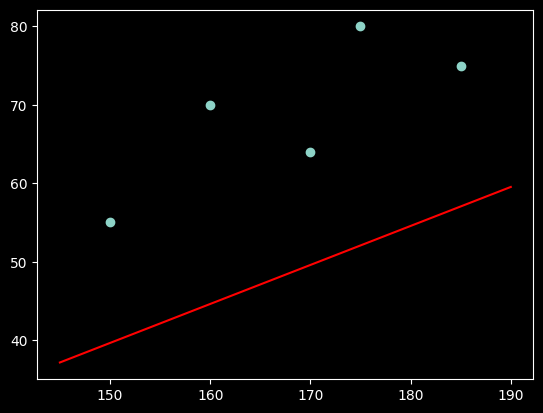

In [ ]:
import torch

a = torch.tensor(0.45, requires_grad=True)
b = torch.tensor(-35.0, requires_grad=True)

L = 0
for xi, yi in zip(x, y):
    L += (yi - (a * xi + b)) ** 2

L.backward()
print(a.grad)
print(b.grad)

LR = 1e-6
a = a.detach() - LR * a.grad
b = b.detach() - LR * b.grad

print(a, b)

plt.figure()
y_plot = a * x_plot + b
plt.plot(x, y, "o")
plt.plot(x_plot, y_plot, "r")

tensor(0.6116) tensor(-34.9990)


/var/folders/14/xj01ch554bdchb7y8wfl2h_m0000gn/T/ipykernel_35495/1916069859.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_plot = a * x_plot + b


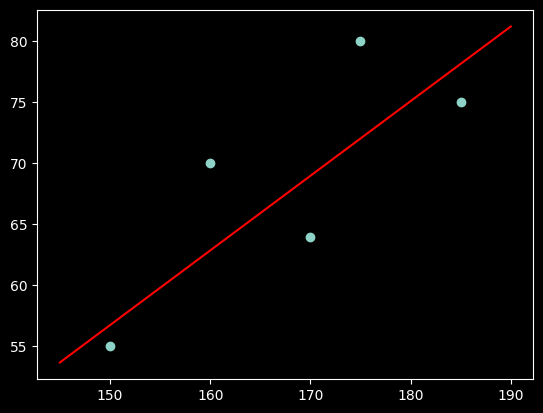

In [ ]:
a.requires_grad = True
b.requires_grad = True

L = 0
for xi, yi in zip(x, y):
    L += (yi - (a * xi + b)) ** 2

L.backward()
LR = 1e-6
a = a.detach() - LR * a.grad
b = b.detach() - LR * b.grad
print(a, b)

plt.figure()
y_plot = a * x_plot + b
plt.plot(x, y, "o")
plt.plot(x_plot, y_plot, "r")

/var/folders/14/xj01ch554bdchb7y8wfl2h_m0000gn/T/ipykernel_35495/3836894389.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_plot = a * x_plot + b


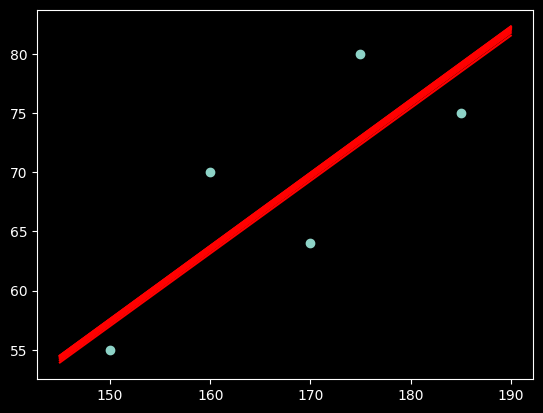

In [ ]:
EPOCH = 10
LR = 1e-6
plt.plot(x, y, "o")
for _ in range(EPOCH):
    a.requires_grad = True
    b.requires_grad = True

    L = 0
    for xi, yi in zip(x, y):
        L += (yi - (a * xi + b)) ** 2

    L.backward()

    a = a.detach() - LR * a.grad
    b = b.detach() - LR * b.grad

    y_plot = a * x_plot + b
    plt.plot(x_plot, y_plot, "r")

/var/folders/14/xj01ch554bdchb7y8wfl2h_m0000gn/T/ipykernel_35495/1801802784.py:28: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_plot = a * x_plot + b


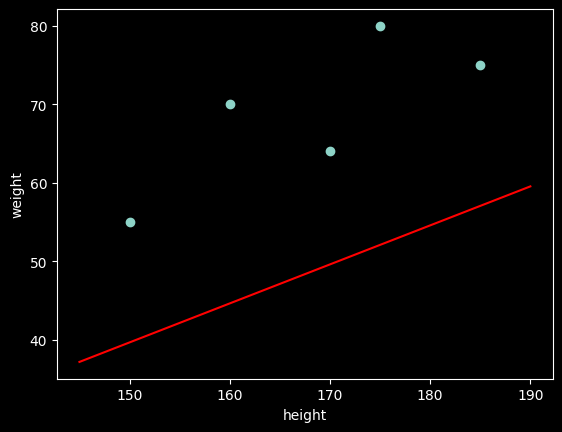

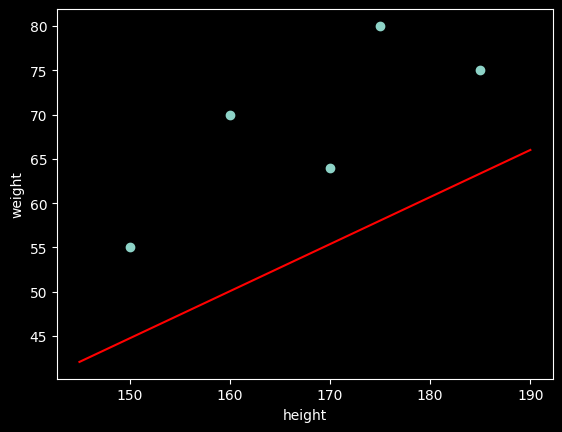

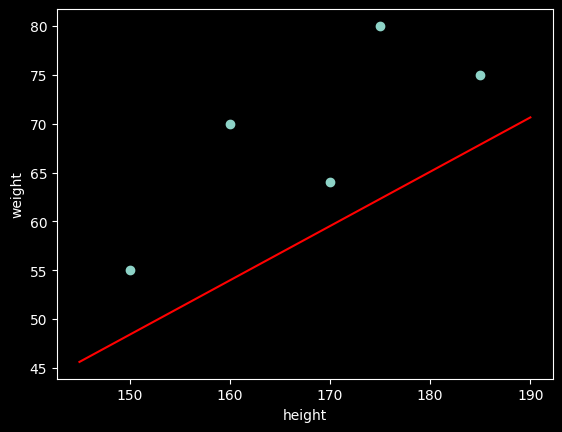

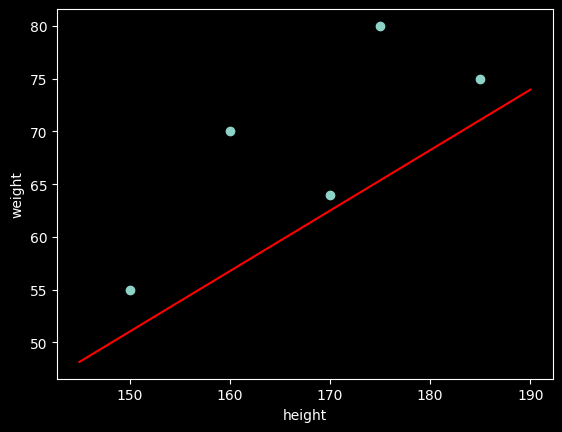

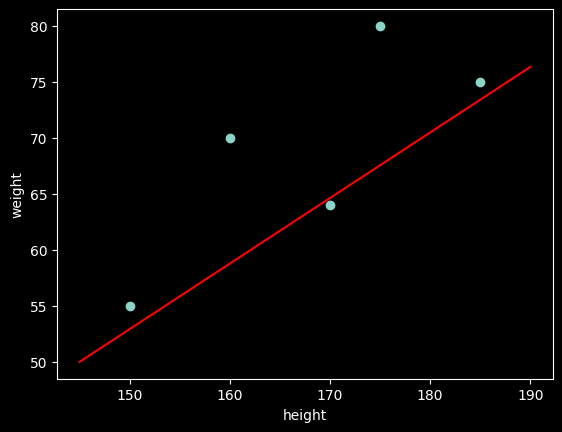

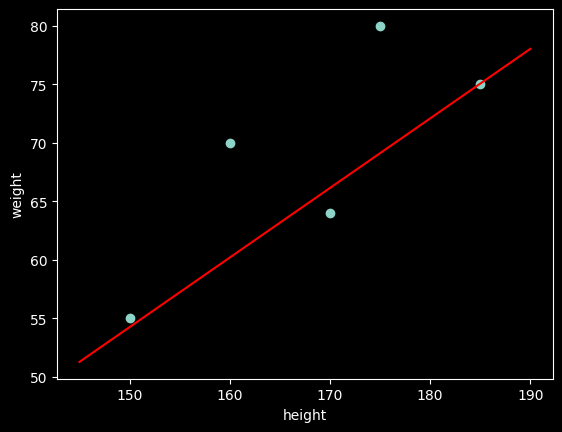

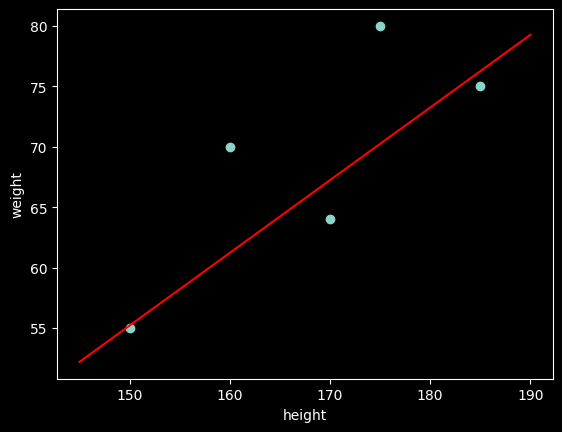

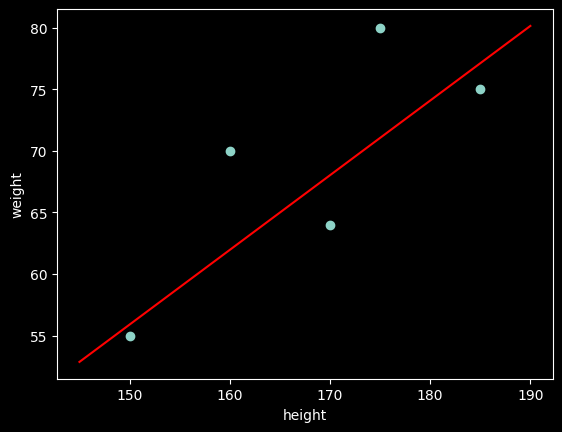

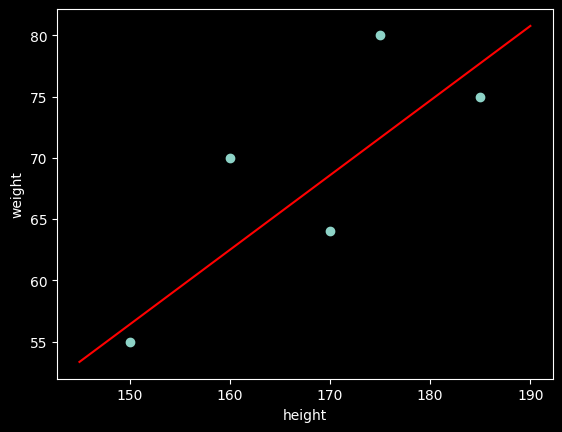

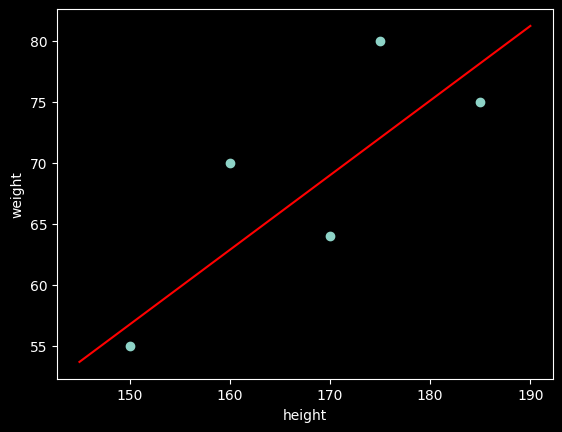

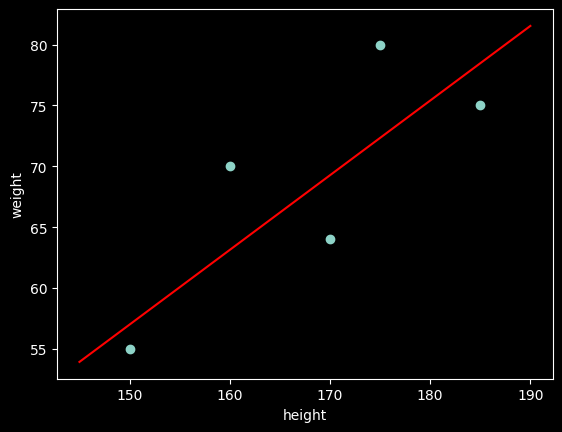

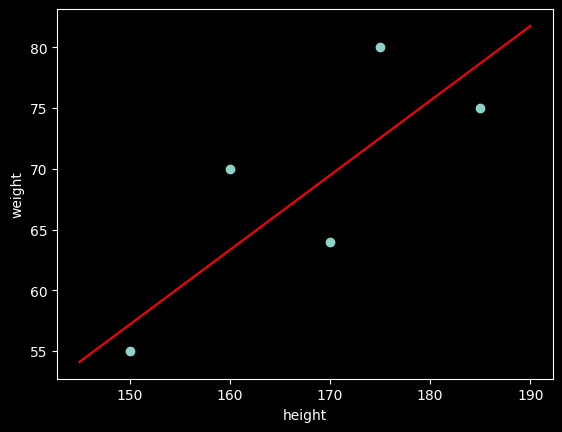

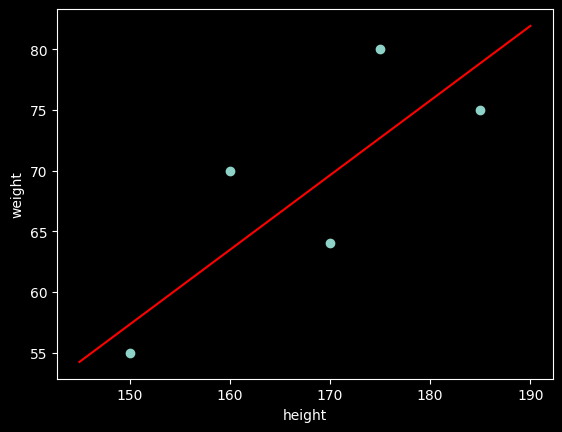

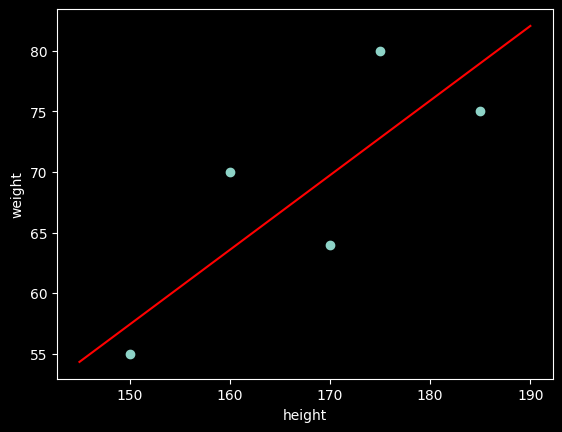

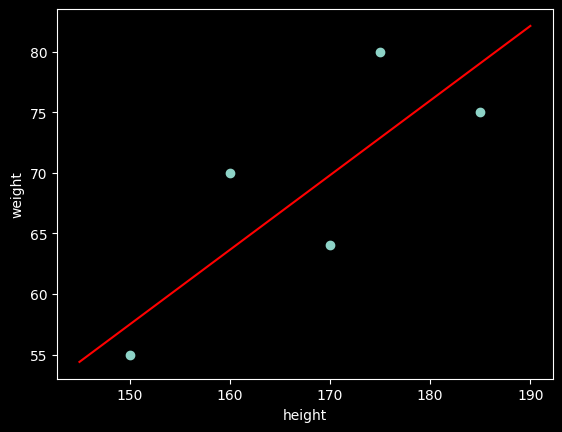

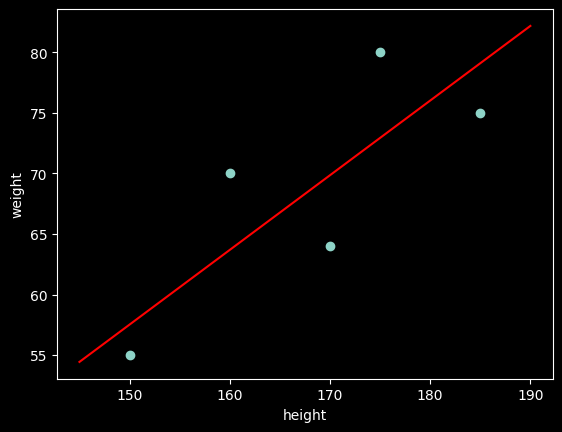

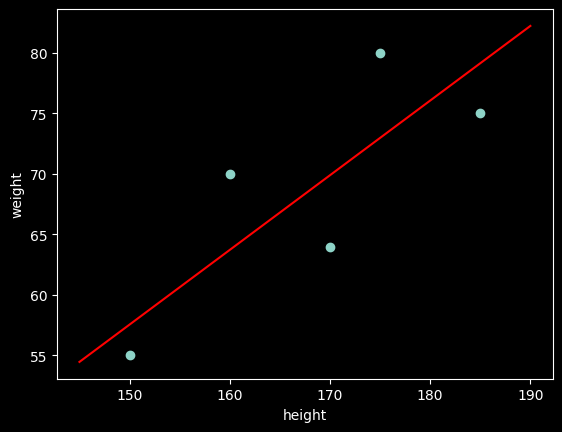

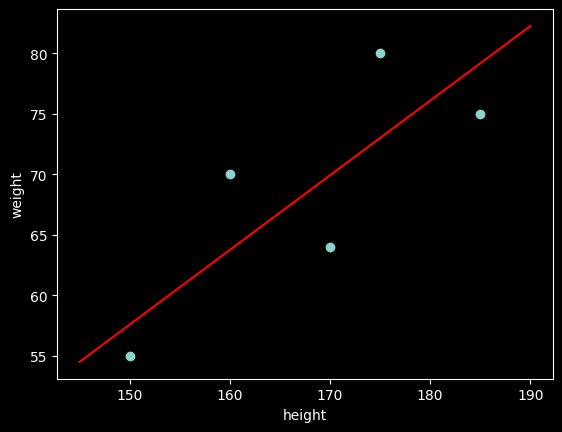

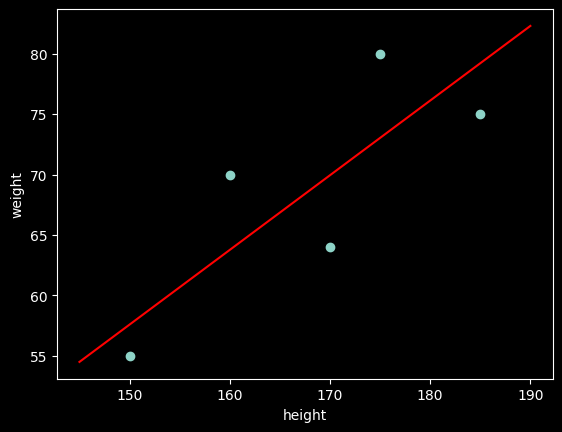

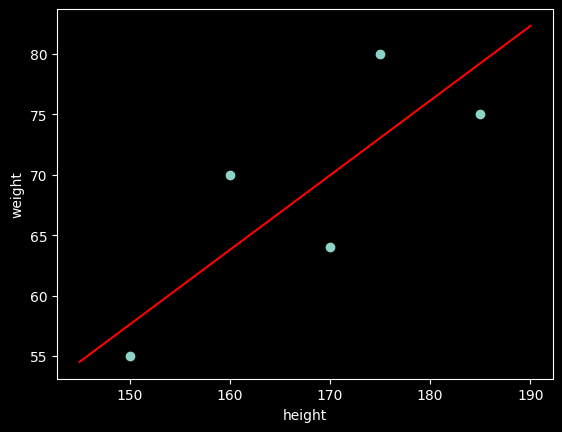

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

x = [150, 160, 170, 175, 185]  # 키
y = [55, 70, 64, 80, 75]  # 몸무게

x_plot = np.linspace(145, 190, 100)

EPOCH = 20
LR = 1e-6
a = torch.tensor(0.45, requires_grad=True)
b = torch.tensor(-35.0, requires_grad=True)

for _ in range(EPOCH):
    a.requires_grad = True
    b.requires_grad = True

    L = 0
    for xi, yi in zip(x, y):
        L += (yi - (a * xi + b)) ** 2

    L.backward()

    a = a.detach() - LR * a.grad
    b = b.detach() - LR * b.grad

    y_plot = a * x_plot + b
    plt.figure()
    plt.plot(x, y, "o")
    plt.plot(x_plot, y_plot, "r")
    plt.xlabel("height")
    plt.ylabel("weight")

[0.44999998807907104, 0.4975450038909912, 0.5316010117530823, 0.555994987487793, 0.5734681487083435, 0.5859839916229248, 0.5949490070343018, 0.6013705134391785, 0.6059702038764954, 0.6092649102210999, 0.6116248369216919, 0.6133152842521667, 0.614526093006134, 0.6153934001922607, 0.6160146594047546, 0.6164596676826477, 0.6167783737182617, 0.6170066595077515, 0.6171702146530151, 0.6172873377799988, 0.6173712611198425]
[-35.0, -34.999717712402344, -34.999515533447266, -34.99937057495117, -34.999267578125, -34.99919128417969, -34.99913787841797, -34.99909973144531, -34.99907302856445, -34.999053955078125, -34.99903869628906, -34.999027252197266, -34.999019622802734, -34.99901580810547, -34.9990119934082, -34.99900817871094, -34.99900436401367, -34.99900436401367, -34.99900436401367, -34.99900436401367, -34.99900436401367]


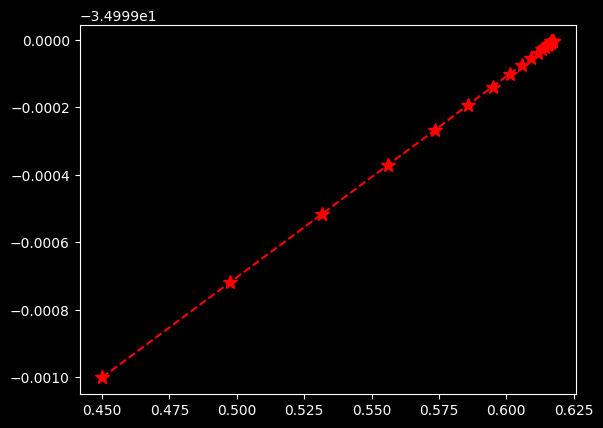

In [ ]:
# history보기 - GD

import numpy as np
import matplotlib.pyplot as plt
import torch

x = [150, 160, 170, 175, 185]  # 키
y = [55, 70, 64, 80, 75]  # 몸무게

x_plot = np.linspace(145, 190, 100)

EPOCH = 20
LR = 1e-6
a = torch.tensor(0.45, requires_grad=True)
b = torch.tensor(-35.0, requires_grad=True)
a_hist = [a.detach().item()]
b_hist = [b.detach().item()]

for _ in range(EPOCH):
    a.requires_grad = True
    b.requires_grad = True

    L = 0
    for xi, yi in zip(x, y):
        L += (yi - (a * xi + b)) ** 2

    L.backward()

    a = a.detach() - LR * a.grad
    b = b.detach() - LR * b.grad

    a_hist.append(a.item())
    b_hist.append(b.item())

plt.plot(a_hist, b_hist, "r*--", markersize=10)
print(a_hist)
print(b_hist)

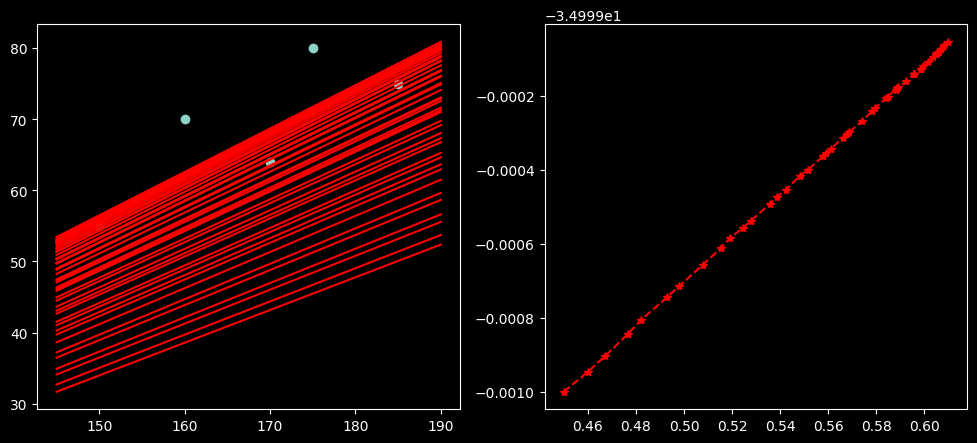

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

x = [150, 160, 170, 175, 185]  # 키
y = [55, 70, 64, 80, 75]  # 몸무게

x_plot = np.linspace(145, 190, 100)

EPOCH = 10
LR = 1e-6

a = torch.tensor(0.45, requires_grad=True)
b = torch.tensor(-35.0, requires_grad=True)
a_hist = [a.detach().item()]
b_hist = [b.detach().item()]

plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(x, y, "o")
for _ in range(EPOCH):
    shuffle_idx = list(range(5))
    random.shuffle(shuffle_idx)

    for i in shuffle_idx:
        a.requires_grad = True
        b.requires_grad = True

        L = (y[i] - (a * x[i] + b)) ** 2
        L.backward()

        a = a.detach() - LR * a.grad
        b = b.detach() - LR * b.grad

        a_hist.append(a.item())
        b_hist.append(b.item())

        y_plot = a.numpy() * x_plot + b.numpy()
        plt.subplot(1, 2, 1)
        plt.plot(x_plot, y_plot, "r")

plt.subplot(1, 2, 2)
plt.plot(a_hist, b_hist, "r*--")